In [11]:
import asyncio
import json
from typing import Literal

from langchain.agents import create_agent
from langchain.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing_extensions import TypedDict


# ============================================================
# 1. Model
# ============================================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    base_url="https://openai.vocareum.com/v1",
    api_key="voc-46640206319004520369916a7f3655c69c53.81266809",
)


# ============================================================
# 2. Tools for the individual agents
# ============================================================

@tool
def get_weather(city: str) -> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny and 25°C."


@tool
def search_database(query: str) -> str:
    """Search the company database."""
    return f"Database result for: {query}"


@tool
def calculate(expression: str) -> str:
    """Calculate a mathematical expression."""
    return str(eval(expression))


# ============================================================
# 3. Create the 3 ReAct agents
# ============================================================

weather_agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="""
    You are the weather agent.
    Answer questions related to weather.
    """
)

database_agent = create_agent(
    model=llm,
    tools=[search_database],
    system_prompt="""
    You are the database agent.
    Answer questions that require searching company data.
    """
)

calculator_agent = create_agent(
    model=llm,
    tools=[calculate],
    system_prompt="""
    You are the calculator agent.
    Answer mathematical questions.
    """
)


# ============================================================
# 4. Graph State
# ============================================================

class State(TypedDict):
    messages: list
    route: str


# ============================================================
# 5. Router
# ============================================================

router_llm = llm.with_structured_output(
    {
        "name": "route",
        "description": "Select which agent should handle the request.",
        "parameters": {
            "type": "object",
            "properties": {
                "agent": {
                    "type": "string",
                    "enum": [
                        "weather",
                        "database",
                        "calculator",
                    ],
                }
            },
            "required": ["agent"],
        },
    }
)


def router(state: State) -> Command[
    Literal["weather_agent", "database_agent", "calculator_agent"]
]:

    messages = state["messages"]

    result = router_llm.invoke([
        {
            "role": "system",
            "content": """
            You are a router.

            Decide which agent should handle the user request.

            weather:
                Weather-related questions.

            database:
                Questions requiring company/database information.

            calculator:
                Mathematical calculations.
            """
        },
        *messages
    ])

    agent = result["agent"]

    print("\n========== ROUTER ==========")
    print("Selected agent:", agent)

    if agent == "weather":
        return Command(
            goto="weather_agent",
            update={"route": "weather"}
        )

    elif agent == "database":
        return Command(
            goto="database_agent",
            update={"route": "database"}
        )

    else:
        return Command(
            goto="calculator_agent",
            update={"route": "calculator"}
        )


# ============================================================
# 6. Agent Nodes
# ============================================================

def run_weather_agent(state: State):

    result = weather_agent.invoke({
        "messages": state["messages"]
    })

    return {
        "messages": result["messages"]
    }


def run_database_agent(state: State):

    result = database_agent.invoke({
        "messages": state["messages"]
    })

    return {
        "messages": result["messages"]
    }


def run_calculator_agent(state: State):

    result = calculator_agent.invoke({
        "messages": state["messages"]
    })

    return {
        "messages": result["messages"]
    }


# ============================================================
# 7. Build Graph
# ============================================================

builder = StateGraph(State)

builder.add_node("router", router)

builder.add_node(
    "weather_agent",
    run_weather_agent
)

builder.add_node(
    "database_agent",
    run_database_agent
)

builder.add_node(
    "calculator_agent",
    run_calculator_agent
)

builder.add_edge(START, "router")

builder.add_edge("weather_agent", END)
builder.add_edge("database_agent", END)
builder.add_edge("calculator_agent", END)

graph = builder.compile()


# ============================================================
# 8. Run
# ============================================================

async def main():

    result = await graph.ainvoke({
        "messages": [
            {
                "role": "user",
                "content": "What is the weather in Cairo?"
            }
        ],
        "route": ""
    })

    print("\n========== FINAL ==========")

    for message in result["messages"]:
        print(
            message
        )

    print(result['messages'])
    
    


# if __name__ == "__main__":
#     asyncio.run(main())

await main()



========== ROUTER ==========
Selected agent: weather

========== FINAL ==========
content='What is the weather in Cairo?' additional_kwargs={} response_metadata={} id='86d2a82a-20d4-44ac-83c8-8946b4175dca'
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 67, 'total_tokens': 82, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ab203f6842', 'id': 'chatcmpl-EDEg3ZdeVKHNkhf8GDBES7GEA5Q4o', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--01a006f9-337d-7442-89e8-2641ac71220e-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Cairo'}, 'id': 'call_x36QlokvYr42WGifr6HWckCQ', 'type': 'tool_call'}] inva

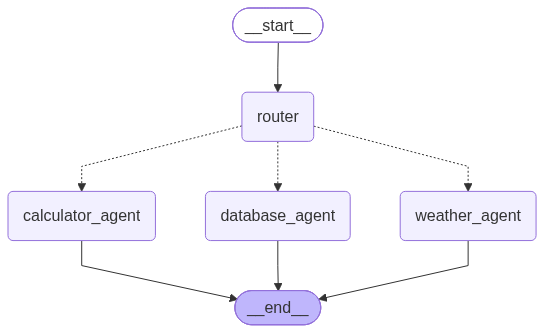

In [ ]:
graph